In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def vis_viva(mu, r, a):
    # Orbital speed from vis-viva: v = sqrt(mu * (2/r - 1/a))
    return math.sqrt(mu * (2.0 / r - 1.0 / a))

def rocket_mass_ratio(delta_v, Isp):
    ve = Isp * g0
    return math.exp(delta_v / ve), ve

def seconds_to_years(seconds):
    return seconds / (3600.0 * 24.0 * 365.25)

In [ ]:
g0 = 9.80665                             # m/s^2
MU_SUN = 1.32712440018e20                # m^3/s^2
AU = 1.495978707e11                      # m
LY = 9.4607e15                           # m
m_payload  = 25000                       # kg
m_structure = 19000.0                    # kg
m_sys_NTP = 400000                       # kg, this is for NTP tanks and hardware, only kept in the first part of the flight 3% of fuel mass
m_total = m_payload + m_sys_NTP
dv_target = 1.8e6           # 1800 km/s target Δv
# Distance to Alpha Centauri (straight line, very simplified)
distance_alpha = 4.367 * LY              # m

# Start in ~1 AU circular heliocentric orbit (LLO → 1 AU neglected)
r1 = AU
# Desired solar perihelion for the Oberth maneuver
rp = 0.014 * AU                          # m

nep_isp_target = 50_000
ve_target = nep_isp_target * g0

p_nep = 10e6 # 10 MW, ideal, no inefficiency
eta = 0.6
p_nep_ineff = p_nep * eta

# Design choice: NEP total Δv capability
dv_nep_design = 1.8e6                    # m/s (1800 km/s)

# NEP stage
Isp_nep = 50000.0                        # s

# Mass ratio and initial mass from rocket equation
mass_ratio = math.exp(dv_target / ve_target)  # ~39.29
m0_nep = mass_ratio * m_payload        # NEP system initial mass
mprop_nep = m0_nep - m_payload         # propellant mass

thrust_ideal = 2 * p_nep / ve_target

thrust_ineff = 2 * p_nep_ineff / ve_target

m_dot_ideal = thrust_ideal / ve_target

m_dot_ineff = thrust_ineff / ve_target

print(ve_target, thrust_ideal, thrust_ineff)

tof_ideal = (m0_nep - m_payload) / m_dot_ideal
tof_ineff = (m0_nep - m_payload) / m_dot_ineff

tof_ideal_years = seconds_to_years(tof_ideal)
tof_ineff_years = seconds_to_years(tof_ineff)

print(tof_ideal_years, tof_ineff_years)

mass_ratio_nep, ve_nep = rocket_mass_ratio(dv_nep_design, Isp_nep)
m0_nep = mass_ratio_nep * m_payload       # initial NEP mass (payload + NEP propellant)
mprop_nep = m0_nep - m_payload           # NEP propellant mass
mdot_nep = thrust_ineff / ve_nep                 # NEP mass flow rate
t_burn_nep = mprop_nep / mdot_nep         # full NEP burn duration

# NTP stage
Isp_ntp = 1274.68                        # s
T_ntp   = 5.0e5                          # N


# determining thrust from power

# Design choice: Oberth burn magnitude at perihelion
dv2_oberth = 2.5e3                       # m/s (2.5 km/s extra at rp)


490332.5 40.78864851911713 24.473189111470276
364.65022481760303 607.750374696005


In [ ]:
# Circular speed at 1 AU
v_circ_1 = math.sqrt(MU_SUN / r1)

# Elliptical plunge orbit with aphelion r1 and perihelion rp
a = 0.5 * (r1 + rp)                        # semi-major axis
v_ell_1 = vis_viva(MU_SUN, r1, a)          # speed at r1 on that ellipse

# Required retrograde delta v at 1 AU to enter the plunge orbit
dv1_injection = abs(v_ell_1 - v_circ_1)

# Speed at perihelion before Oberth burn
v_peri_before = vis_viva(MU_SUN, rp, a)

# Parabolic (escape) speed at rp: "needed" exit speed to just escape the Sun
v_parabolic_rp = math.sqrt(2.0 * MU_SUN / rp)

# Actual perihelion speed after giving dv2_oberth tangentially at rp
v_peri_after = v_peri_before + dv2_oberth

# Hyperbolic excess speed (v_inf) relative to the Sun after NTP stage
v_inf_sun = math.sqrt(max(0.0, v_peri_after**2 - 2.0 * MU_SUN / rp))

# Total NTP Δv (injection+Oberth)
dv_total_ntp = dv1_injection + dv2_oberth

# NTP mass ratio and propellant mass
mass_ratio_ntp, ve_ntp = rocket_mass_ratio(dv_total_ntp, Isp_ntp)

# Final mass after NTP burns (and NTP stage assumed dry mass ≈ 0): this is m0_nep
m_final_after_ntp = m0_nep
m0_ntp   = mass_ratio_ntp * (m_final_after_ntp + m_sys_NTP)
mprop_ntp = m0_ntp - m_final_after_ntp

# NTP burn time (if burns were continuous at T_ntp)
mdot_ntp = T_ntp / ve_ntp
t_burn_ntp = mprop_ntp / mdot_ntp

# Time from 1 AU down to perihelion on the plunge ellipse
T_ellipse = 2.0 * math.pi * math.sqrt(a**3 / MU_SUN)
t_fall = 0.5 * T_ellipse                   # half-period: aphelion → perihelion


NTP STAGE (INCLUDING NEP MASS)
NTP Isp:                          1274.68 s
NTP exhaust velocity ve:          12.50 km/s
NTP Thrust:                       500000.00 N
NTP Mass flow mdot:               40.00 kg/s
Injection Δv at 1 AU:             24.84 km/s (retrograde)
Oberth Δv at perihelion:          2.50 km/s
Total NTP Δv:                     27.34 km/s
NTP mass ratio m0/mf:             8.906
Final mass after NTP (NEP stage): 982258.2 kg
Initial mass before NTP burns:    12310859.3 kg
NTP propellant mass:              10928601.1 kg
NTP burn time:                    0.01 years


SOLAR PERIHELION DYNAMICS
Perihelion radius:                0.0140 AU
Speed at perihelion, before Oberth:  353.5 km/s
Parabolic (escape) speed at rp:      356.0 km/s  <-- 'needed' to just escape
Speed at perihelion, after Oberth:   356.0 km/s   <-- 'actual' from NTP
Solar hyperbolic v_inf:               4.9 km/s
Fall time 1 AU → rp:                  0.18 years
Fall time s                           5696316.51


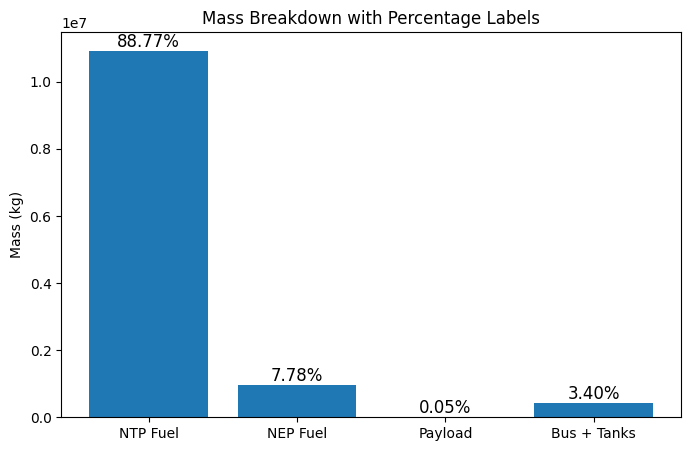

In [ ]:
dt_step = 5e6
T_ideal = thrust_ideal
T_ineff = thrust_ineff
# --- NEP RK2 simulation with time history ---

def simulate_case_with_history(label, T, ve, m0, mf, v0, distance_target, dt=5.0e6):
    """
    RK2 1D trajectory with constant-thrust NEP until propellant is exhausted,
    then ballistic coast, starting from speed v0 at x=0.
    Returns both final scalars AND history arrays.
    """
    mdot = T / ve                      # kg/s (constant during burn)
    t_burn = (m0 - mf) / mdot          # analytical burn duration

    # Initial conditions
    t = 0.0                            # time (s)
    x = 0.0                            # position (m)
    v = v0                             # velocity (m/s)
    m = m0                             # mass (kg)

    max_time = 2.0e11                  # safety cap (~6340 years)

    # History arrays
    t_hist = [t]
    x_hist = [x]
    v_hist = [v]
    m_hist = [m]

    while x < distance_target and t < max_time:
        # ---- Step 1: derivatives at beginning of step ----
        if t < t_burn:
            T_now = T
            mdot_now = mdot
        else:
            T_now = 0.0
            mdot_now = 0.0

        a_now = T_now / m if m > 0.0 else 0.0

        dx1 = v
        dv1 = a_now
        dm1 = -mdot_now

        # ---- Step 2: midpoint estimates ----
        t_mid = t + 0.5 * dt
        x_mid = x + 0.5 * dx1 * dt
        v_mid = v + 0.5 * dv1 * dt
        m_mid = m + 0.5 * dm1 * dt

        if t_mid < t_burn:
            T_mid = T
            mdot_mid = mdot
        else:
            T_mid = 0.0
            mdot_mid = 0.0

        a_mid = T_mid / m_mid if m_mid > 0.0 else 0.0

        dx2 = v_mid
        dv2 = a_mid
        dm2 = -mdot_mid

        # ---- Step 3: full update ----
        x += dx2 * dt
        v += dv2 * dt
        m += dm2 * dt
        t += dt

        # Prevent mass from dropping below dry mass
        if m < mf:
            m = mf

        # Save history
        t_hist.append(t)
        x_hist.append(x)
        v_hist.append(v)
        m_hist.append(m)

    return {
        "label":   label,
        "T":       T,
        "mdot":    mdot,
        "t_burn":  t_burn,
        "t_total": t,
        "x_final": x,
        "v_final": v,
        "m_final": m,
        "t_hist":  t_hist,
        "x_hist":  x_hist,
        "v_hist":  v_hist,
        "m_hist":  m_hist,
    }

# Re-run both NEP cases with history using the variables from your script
res_ideal_hist = simulate_case_with_history(
    "Ideal NEP (η = 1.0)",
    T_ideal, ve_target, m0_nep, m_payload, v_inf_sun,
    distance_alpha, dt_step
)

res_ineff_hist = simulate_case_with_history(
    "Inefficient NEP (η = 0.6)",
    T_ineff, ve_target, m0_nep, m_payload, v_inf_sun,
    distance_alpha, dt_step
)

# -----------------------------
# Print results
# -----------------------------
def print_result(res):
    print(f"{res['label']}")
    print(f"Thrust T:                 {res['T']:.2f} N")
    print(f"Mass flow mdot:           {res['mdot']:.4e} kg/s")
    print(f"Burn time (analytic):     {seconds_to_years(res['t_burn']):.2f} years")
    print(f"Total mission time:       {seconds_to_years(res['t_total']):.1f} years")
    print(f"Final distance:           {res['x_final'] / distance_alpha:.3f} × Alpha Cen distance")
    print(f"Final velocity at arrival:{res['v_final'] / 1000:.1f} km/s")
    print(f"Final mass:               {res['m_final']:.1f} kg")
    print()

print("\nNTP STAGE (INCLUDING NEP MASS)")
print(f"NTP Isp:                          {Isp_ntp:.2f} s")
print(f"NTP exhaust velocity ve:          {ve_ntp/1000:.2f} km/s")
print(f"NTP Thrust:                       {T_ntp:.2f} N")
print(f"NTP Mass flow mdot:               {mdot_ntp:.2f} kg/s")
print(f"Injection Δv at 1 AU:             {dv1_injection/1000:.2f} km/s (retrograde)")
print(f"Oberth Δv at perihelion:          {dv2_oberth/1000:.2f} km/s")
print(f"Total NTP Δv:                     {dv_total_ntp/1000:.2f} km/s")
print(f"NTP mass ratio m0/mf:             {mass_ratio_ntp:.3f}")
print(f"Final mass after NTP (NEP stage): {m_final_after_ntp:.1f} kg")
print(f"Initial mass before NTP burns:    {m0_ntp:.1f} kg")
print(f"NTP propellant mass:              {(mprop_ntp - m_sys_NTP):.1f} kg")
print(f"NTP burn time:                    {seconds_to_years(t_burn_ntp):.2f} years\n")

print("\nSOLAR PERIHELION DYNAMICS")
print(f"Perihelion radius:                {rp/AU:.4f} AU")
print(f"Speed at perihelion, before Oberth:  {v_peri_before/1000:.1f} km/s")
print(f"Parabolic (escape) speed at rp:      {v_parabolic_rp/1000:.1f} km/s  <-- 'needed' to just escape")
print(f"Speed at perihelion, after Oberth:   {v_peri_after/1000:.1f} km/s   <-- 'actual' from NTP")
print(f"Solar hyperbolic v_inf:               {v_inf_sun/1000:.1f} km/s")
print(f"Fall time 1 AU → rp:                  {seconds_to_years(t_fall):.2f} years")
print(f"Fall time s                           {t_fall:.2f}")
print(f"\nNEP Isp:                  {Isp_nep:.0f} s")
print(f"Exhaust velocity ve:      {ve_target/1000:.2f} km/s")
print(f"Target Δv:                {dv_target/1000:.0f} km/s")
print(f"Mass ratio m0/mf:         {mass_ratio:.2f}")
print(f"Initial NEP mass m0:      {m0_nep:.1f} kg")
print(f"Propellant mass:          {mprop_nep:.1f} kg\n")

print(f"RK2 step size:            {seconds_to_years(dt_step):.2f} years\n")

print_result(res_ideal_hist)
print_result(res_ineff_hist)
values = [mprop_ntp - m_sys_NTP,
          m_final_after_ntp - m_payload,
          m_payload - m_structure,
          m_structure + m_sys_NTP]

labels = ["NTP Fuel", "NEP Fuel", "Payload", "Bus + Tanks"]
total = sum(values)

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values)

# Add percentage labels above each bar
for bar, val in zip(bars, values):
    height = bar.get_height()
    pct = 100 * val / total
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{pct:.2f}%",
             ha="center", va="bottom", fontsize=12)

plt.ylabel("Mass (kg)")
plt.title("Mass Breakdown with Percentage Labels")
plt.show()


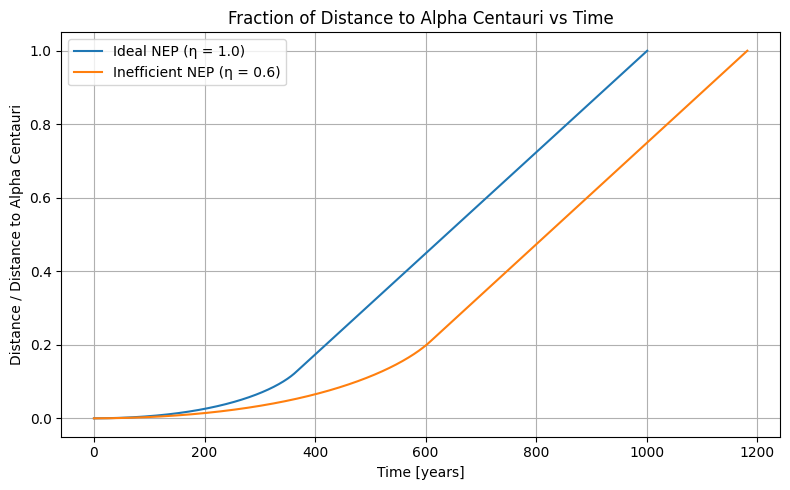

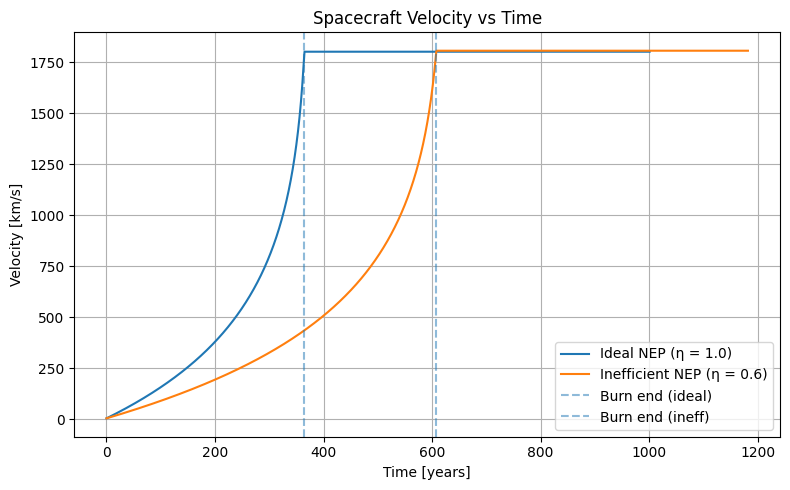

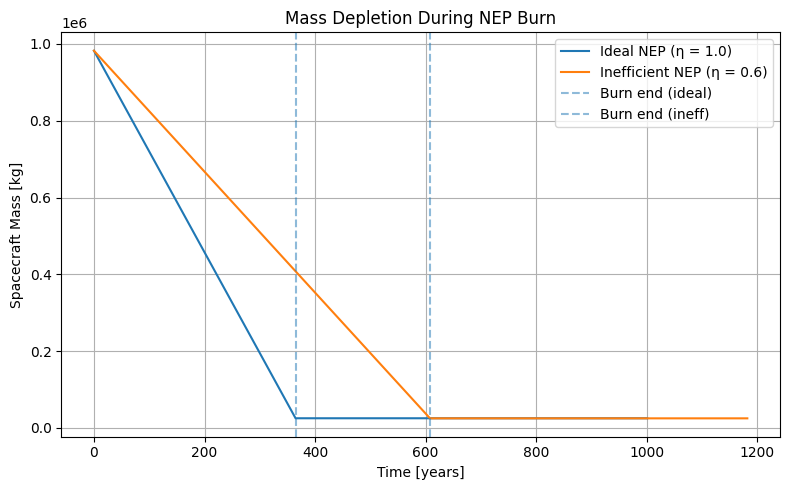

In [ ]:
def arr_seconds_to_years(t_list):
    return [seconds_to_years(t) for t in t_list]

# Convenience
t_ideal_years  = arr_seconds_to_years(res_ideal_hist["t_hist"])
t_ineff_years  = arr_seconds_to_years(res_ineff_hist["t_hist"])

x_ideal_frac   = [x / distance_alpha for x in res_ideal_hist["x_hist"]]
x_ineff_frac   = [x / distance_alpha for x in res_ineff_hist["x_hist"]]

v_ideal_kms    = [v / 1000.0 for v in res_ideal_hist["v_hist"]]
v_ineff_kms    = [v / 1000.0 for v in res_ineff_hist["v_hist"]]

m_ideal        = res_ideal_hist["m_hist"]
m_ineff        = res_ineff_hist["m_hist"]

t_burn_ideal_y = seconds_to_years(res_ideal_hist["t_burn"])
t_burn_ineff_y = seconds_to_years(res_ineff_hist["t_burn"])
# 1) Distance progress toward Alpha Centauri
plt.figure(figsize=(8, 5))
plt.plot(t_ideal_years, x_ideal_frac, label="Ideal NEP (η = 1.0)")
plt.plot(t_ineff_years, x_ineff_frac, label="Inefficient NEP (η = 0.6)")
plt.xlabel("Time [years]")
plt.ylabel("Distance / Distance to Alpha Centauri")
plt.title("Fraction of Distance to Alpha Centauri vs Time")
plt.grid(True)
plt.legend()
plt.tight_layout()

# 2) Velocity vs time
plt.figure(figsize=(8, 5))
plt.plot(t_ideal_years, v_ideal_kms, label="Ideal NEP (η = 1.0)")
plt.plot(t_ineff_years, v_ineff_kms, label="Inefficient NEP (η = 0.6)")
plt.axvline(t_burn_ideal_y, linestyle="--", alpha=0.5, label="Burn end (ideal)")
plt.axvline(t_burn_ineff_y, linestyle="--", alpha=0.5, label="Burn end (ineff)")
plt.xlabel("Time [years]")
plt.ylabel("Velocity [km/s]")
plt.title("Spacecraft Velocity vs Time")
plt.grid(True)
plt.legend()
plt.tight_layout()

# 3) Mass vs time NEP
plt.figure(figsize=(8, 5))
plt.plot(t_ideal_years, m_ideal, label="Ideal NEP (η = 1.0)")
plt.plot(t_ineff_years, m_ineff, label="Inefficient NEP (η = 0.6)")
plt.axvline(t_burn_ideal_y, linestyle="--", alpha=0.5, label="Burn end (ideal)")
plt.axvline(t_burn_ineff_y, linestyle="--", alpha=0.5, label="Burn end (ineff)")
plt.xlabel("Time [years]")
plt.ylabel("Spacecraft Mass [kg]")
plt.title("Mass Depletion During NEP Burn")
plt.grid(True)
plt.legend()
plt.tight_layout()


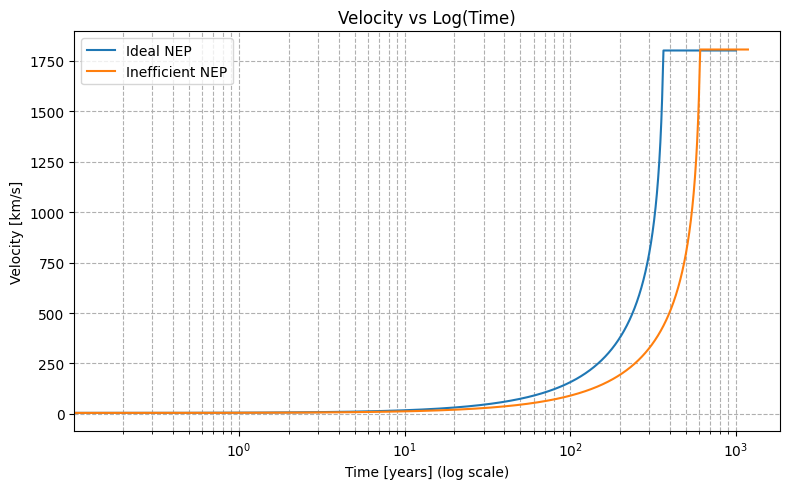

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t_ideal_years, v_ideal_kms, label="Ideal NEP")
plt.plot(t_ineff_years, v_ineff_kms, label="Inefficient NEP")
plt.xscale("log")
plt.xlabel("Time [years] (log scale)")
plt.ylabel("Velocity [km/s]")
plt.title("Velocity vs Log(Time)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()


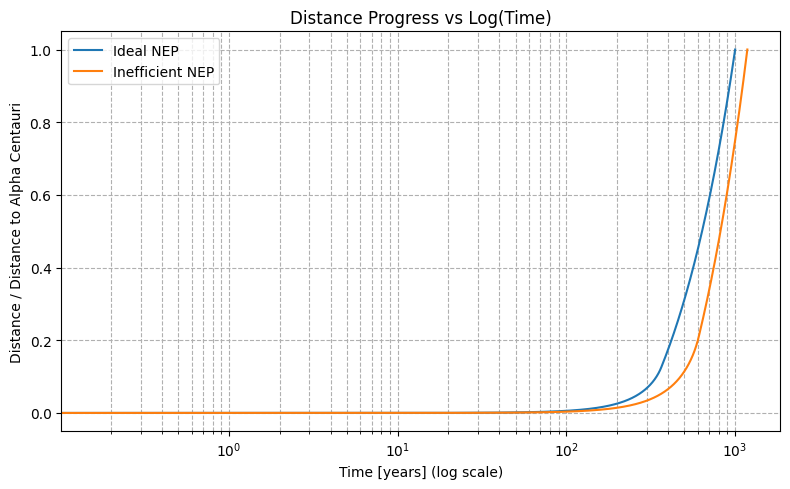

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t_ideal_years, x_ideal_frac, label="Ideal NEP")
plt.plot(t_ineff_years, x_ineff_frac, label="Inefficient NEP")
plt.xscale("log")
plt.xlabel("Time [years] (log scale)")
plt.ylabel("Distance / Distance to Alpha Centauri")
plt.title("Distance Progress vs Log(Time)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()


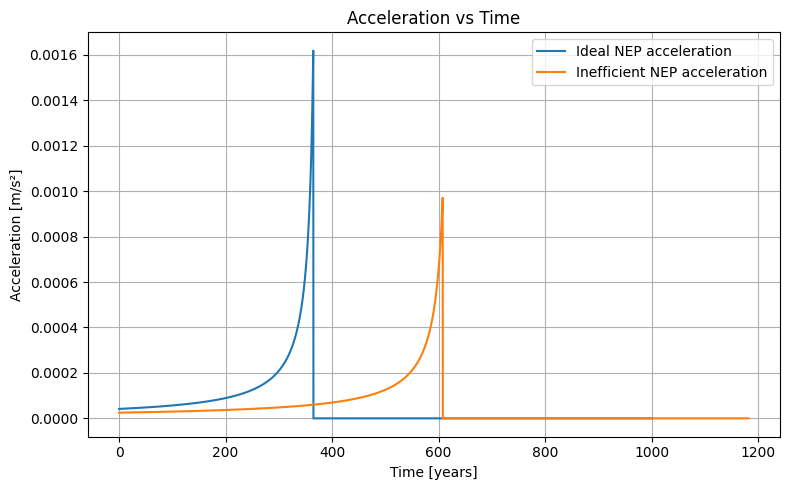

In [ ]:
# Correct acceleration history
a_ideal = []
a_ineff = []

for t, m in zip(res_ideal_hist["t_hist"], m_ideal):
    if t < res_ideal_hist["t_burn"]:
        a_ideal.append(T_ideal / m)
    else:
        a_ideal.append(0.0)

for t, m in zip(res_ineff_hist["t_hist"], m_ineff):
    if t < res_ineff_hist["t_burn"]:
        a_ineff.append(T_ineff / m)
    else:
        a_ineff.append(0.0)

# Replot
plt.figure(figsize=(8,5))
plt.plot(t_ideal_years, a_ideal, label="Ideal NEP acceleration")
plt.plot(t_ineff_years, a_ineff, label="Inefficient NEP acceleration")
plt.xlabel("Time [years]")
plt.ylabel("Acceleration [m/s²]")
plt.title("Acceleration vs Time")
plt.grid(True)
plt.legend()
plt.tight_layout()



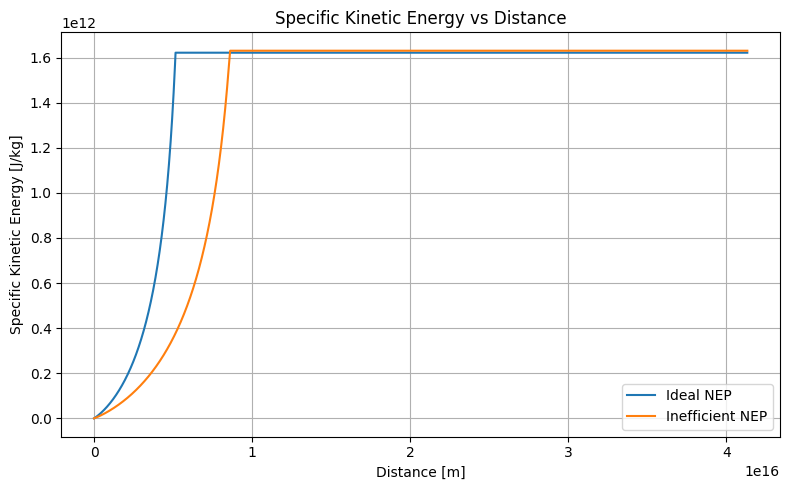

In [ ]:
KE_ideal = [0.5 * v**2 for v in res_ideal_hist["v_hist"]]
KE_ineff = [0.5 * v**2 for v in res_ineff_hist["v_hist"]]

plt.figure(figsize=(8,5))
plt.plot(res_ideal_hist["x_hist"], KE_ideal, label="Ideal NEP")
plt.plot(res_ineff_hist["x_hist"], KE_ineff, label="Inefficient NEP")
plt.xlabel("Distance [m]")
plt.ylabel("Specific Kinetic Energy [J/kg]")
plt.title("Specific Kinetic Energy vs Distance")
plt.grid(True)
plt.legend()
plt.tight_layout()


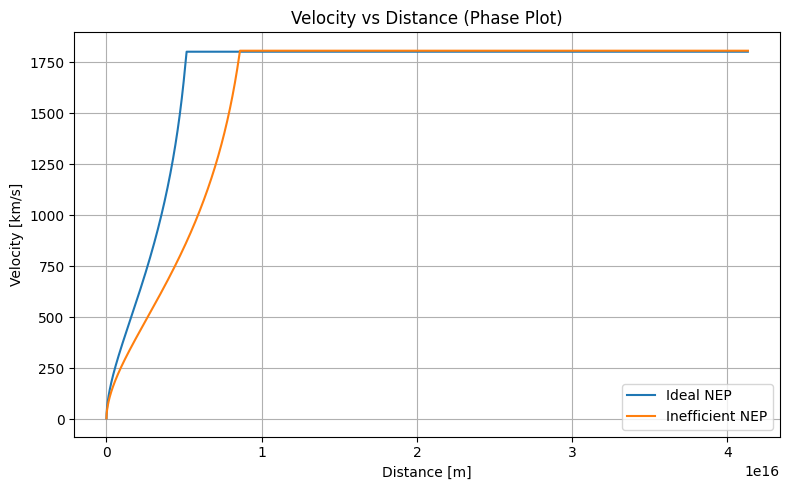

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(res_ideal_hist["x_hist"], v_ideal_kms, label="Ideal NEP")
plt.plot(res_ineff_hist["x_hist"], v_ineff_kms, label="Inefficient NEP")
plt.xlabel("Distance [m]")
plt.ylabel("Velocity [km/s]")
plt.title("Velocity vs Distance (Phase Plot)")
plt.grid(True)
plt.legend()
plt.tight_layout()


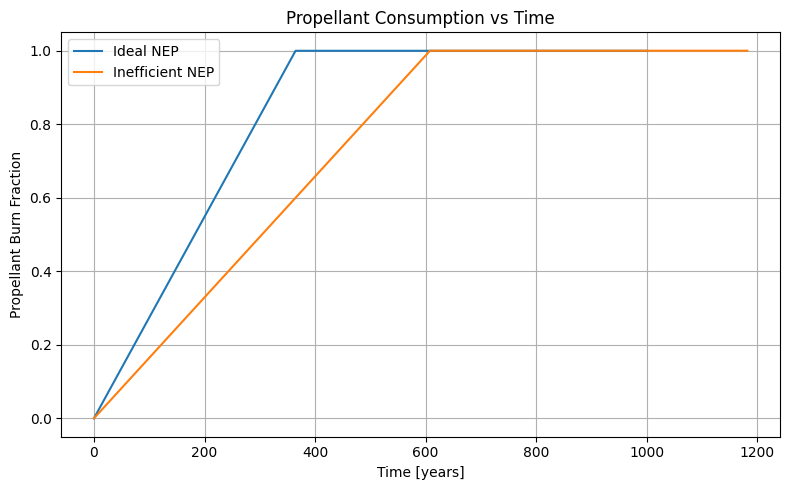

In [ ]:
prop_frac_ideal = [(m0_nep - m) / (m0_nep - m_payload) for m in m_ideal]
prop_frac_ineff = [(m0_nep - m) / (m0_nep - m_payload) for m in m_ineff]

plt.figure(figsize=(8,5))
plt.plot(t_ideal_years, prop_frac_ideal, label="Ideal NEP")
plt.plot(t_ineff_years, prop_frac_ineff, label="Inefficient NEP")
plt.xlabel("Time [years]")
plt.ylabel("Propellant Burn Fraction")
plt.title("Propellant Consumption vs Time")
plt.grid(True)
plt.legend()
plt.tight_layout()


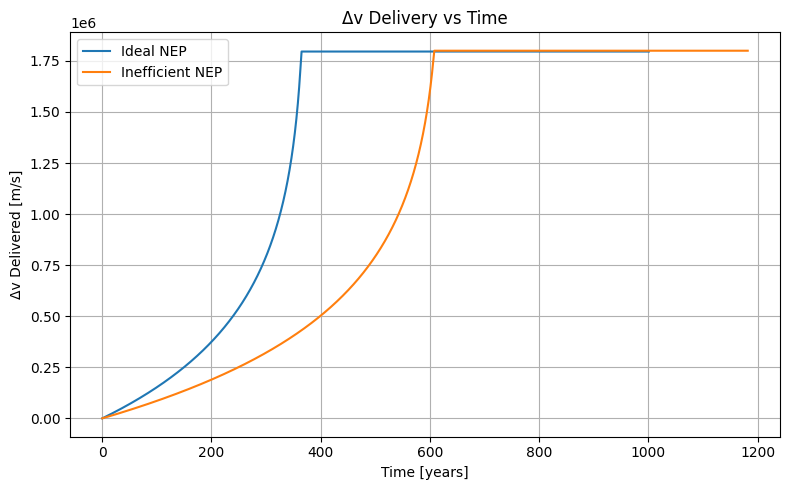

In [ ]:
dv_ideal = []
dv_ineff = []

# incremental Tsiolkovsky
for i in range(1, len(m_ideal)):
    dm = m_ideal[i] - m_ideal[i-1]
    m_avg = 0.5 * (m_ideal[i] + m_ideal[i-1])
    dv_ideal.append(-ve_target * dm / m_avg)

for i in range(1, len(m_ineff)):
    dm = m_ineff[i] - m_ineff[i-1]
    m_avg = 0.5 * (m_ineff[i] + m_ineff[i-1])
    dv_ineff.append(-ve_target * dm / m_avg)

# cumulative integrate
dv_ideal_cum = [sum(dv_ideal[:i]) for i in range(len(dv_ideal))]
dv_ineff_cum = [sum(dv_ineff[:i]) for i in range(len(dv_ineff))]

plt.figure(figsize=(8,5))
plt.plot(t_ideal_years[1:], dv_ideal_cum, label="Ideal NEP")
plt.plot(t_ineff_years[1:], dv_ineff_cum, label="Inefficient NEP")
plt.xlabel("Time [years]")
plt.ylabel("Δv Delivered [m/s]")
plt.title("Δv Delivery vs Time")
plt.grid(True)
plt.legend()
plt.tight_layout()


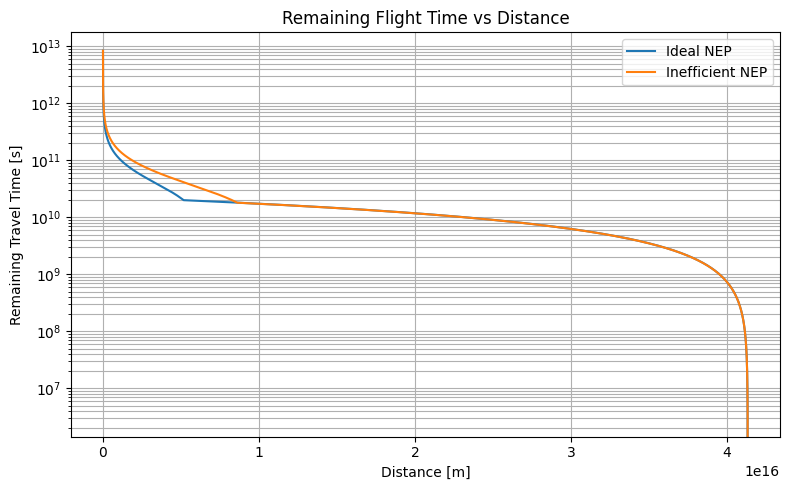

In [ ]:
total_distance = distance_alpha

remaining_time_ideal = [
    (total_distance - x)/v if v > 0 else float('inf')
    for x, v in zip(res_ideal_hist["x_hist"], res_ideal_hist["v_hist"])
]

remaining_time_ineff = [
    (total_distance - x)/v if v > 0 else float('inf')
    for x, v in zip(res_ineff_hist["x_hist"], res_ineff_hist["v_hist"])
]

plt.figure(figsize=(8,5))
plt.plot(res_ideal_hist["x_hist"], remaining_time_ideal, label="Ideal NEP")
plt.plot(res_ineff_hist["x_hist"], remaining_time_ineff, label="Inefficient NEP")
plt.xlabel("Distance [m]")
plt.ylabel("Remaining Travel Time [s]")
plt.title("Remaining Flight Time vs Distance")
plt.yscale("log")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()


In [ ]:
def prandtl_meyer(M, gamma):
    """
    Prandtl–Meyer function ν(M) in degrees.
    """
    g = gamma
    term = math.sqrt((g + 1.0) / (g - 1.0))
    return math.degrees(
        term * math.atan(math.sqrt((g - 1.0) / (g + 1.0) * (M**2 - 1.0)))
        - math.atan(math.sqrt(M**2 - 1.0))
    )

def prandtl_meyer_inv(nu_deg, gamma, M_guess=2.0, iters=40):
    """
    Invert Prandtl–Meyer function to get Mach number from ν (deg).
    Newton iteration.
    """
    g = gamma
    nu_target = math.radians(nu_deg)
    M = max(M_guess, 1.01)

    for _ in range(iters):
        root = math.sqrt(max(M**2 - 1.0, 1e-10))
        term1 = math.sqrt((g + 1.0) / (g - 1.0))

        nu = term1 * math.atan(math.sqrt((g - 1.0) / (g + 1.0) * (M**2 - 1.0))) \
             - math.atan(math.sqrt(M**2 - 1.0))

        dnudM = (
            term1 * ((g - 1.0) / (g + 1.0)) * M /
            (root * (1.0 + (g - 1.0) / (g + 1.0) * (M**2 - 1.0)))
            - M / (root * (1.0 + (M**2 - 1.0)))
        )

        if abs(dnudM) < 1e-10:
            dnudM = 1e-10

        M_new = M - (nu - nu_target) / dnudM
        M = max(M_new, 1.001)

    return M

def mach_angle(M):
    """
    Mach angle μ(M) in degrees.
    """
    return math.degrees(math.asin(1.0 / M))

def slope_C_minus(theta_deg, mu_deg):
    """
    Slope dy/dx of a C- characteristic.
    """
    return math.tan(math.radians(theta_deg - mu_deg))

def slope_C_plus(theta_deg, mu_deg):
    """
    Slope dy/dx of a C+ characteristic.
    """
    return math.tan(math.radians(theta_deg + mu_deg))

def intersect_char_with_wall(x0, y0, m, x_wall, y_wall):
    """
    Find intersection of a line y = y0 + m (x - x0) with a piecewise-linear wall
    defined by (x_wall[i], y_wall[i]).
    Returns (x_int, y_int) or the last wall point if no sign change is found.
    """
    for i in range(len(x_wall) - 1):
        x1, x2 = x_wall[i], x_wall[i+1]
        y1, y2 = y_wall[i], y_wall[i+1]

        if x2 <= x0:
            continue

        yL1 = y0 + m * (x1 - x0)
        yL2 = y0 + m * (x2 - x0)

        d1 = yL1 - y1
        d2 = yL2 - y2

        if d1 * d2 <= 0.0:
            if abs(d2 - d1) < 1e-12:
                x_int = 0.5 * (x1 + x2)
            else:
                x_int = x1 - d1 * (x2 - x1) / (d2 - d1)
            y_int = y0 + m * (x_int - x0)
            return x_int, y_int

    return x_wall[-1], y_wall[-1]

In [ ]:
def design_min_length_nozzle(Me, gamma, n_waves=30, Rt=1.0):
    """
    Simple minimum-length de Laval nozzle design using Method of Characteristics.
    - Me: exit Mach number
    - gamma: specific heat ratio
    - n_waves: number of characteristic waves in the expansion fan
    - Rt: throat radius used as normalization (code is dimensionless in Rt)

    Returns:
      chars_minus: list of characteristic lines (C-) from throat to centerline
      chars_plus : list of characteristic lines (C+) from centerline to wall
      x_wall, y_wall: wall contour (upper half)
    """
    # Exit Prandtl–Meyer angle and max wall angle at throat
    nu_e = prandtl_meyer(Me, gamma)
    theta_max = nu_e / 2.0

    # Throat corner state
    throat = dict(x=0.0, y=Rt,
                  theta=0.0, nu=0.0,
                  M=1.0001, mu=mach_angle(1.0001))

    # Start fan with a small nonzero angle
    theta1 = theta_max / (n_waves * 1.5)
    dtheta = (theta_max - theta1) / (n_waves - 1)

    fan_states = []
    for i in range(n_waves):
        theta_i = theta1 + i * dtheta
        nu_i = max(theta_i, 0.5)  # avoid ν≈0 numerical trouble
        M_i = prandtl_meyer_inv(nu_i, gamma, M_guess=1.1 + 0.2 * i)
        mu_i = mach_angle(M_i)
        fan_states.append(dict(
            x=throat["x"], y=throat["y"],
            theta=theta_i, nu=nu_i, M=M_i, mu=mu_i
        ))

    # C- characteristics: throat corner → centerline
    chars_minus = [[] for _ in range(n_waves)]
    for i in range(n_waves):
        chars_minus[i].append((throat["x"], throat["y"]))

    centerline_points = []
    for i, P in enumerate(fan_states):
        m_minus = slope_C_minus(P["theta"], P["mu"])
        x0, y0 = P["x"], P["y"]
        x_c = x0 - y0 / m_minus
        y_c = 0.0
        chars_minus[i].append((x_c, y_c))
        centerline_points.append(dict(x=x_c, y=y_c))

    # Guess nozzle length based on centerline extent
    x_exit = max(pt["x"] for pt in centerline_points) * 2.5
    x_wall = np.linspace(0.0, x_exit, 400)

    # Half-cosine decay for wall angle (minimum-length style)
    theta_wall = theta_max * 0.5 * (1.0 + np.cos(np.pi * x_wall / x_exit))
    y_wall = Rt + np.cumsum(np.tan(np.radians(theta_wall))) * (x_wall[1] - x_wall[0])

    # C+ characteristics: centerline → wall
    chars_plus = []
    theta_c = 0.0
    nu_c = max(theta_max / 2.0, 0.5)
    M_c = prandtl_meyer_inv(nu_c, gamma, M_guess=Me)
    mu_c = mach_angle(M_c)
    m_plus = slope_C_plus(theta_c, mu_c)

    for Pc in centerline_points:
        x0, y0 = Pc["x"], 0.0
        x_int, y_int = intersect_char_with_wall(x0, y0, m_plus, x_wall, y_wall)
        chars_plus.append([(x0, y0), (x_int, y_int)])

    return chars_minus, chars_plus, x_wall, y_wall

In [ ]:
g0 = 9.80665
R_univ = 8.31446261815324
M_H2   = 2.016e-3
R_H2   = R_univ / M_H2  # ≈ 4124 J/kg/K

def area_ratio_from_M(Me, gamma):
    """
    Isentropic area ratio A/At for a given Mach number Me.
    """
    term = (2.0 / (gamma + 1.0)) * (1.0 + 0.5 * (gamma - 1.0) * Me**2)
    exp  = (gamma + 1.0) / (2.0 * (gamma - 1.0))
    return (1.0 / Me) * term**exp

def Isp_from_Me(Me, gamma, R, T0, Pc, mdot, At, p_amb=0.0):
    """
    Given exit Mach Me and chamber conditions, compute:
      Isp, thrust, Ae, Ae/At, pe, Te, Ve
    """
    Te = T0 / (1.0 + 0.5 * (gamma - 1.0) * Me**2)
    pe = Pc * (Te / T0)**(gamma / (gamma - 1.0))
    ae = math.sqrt(gamma * R * Te)
    Ve = Me * ae

    AeAt = area_ratio_from_M(Me, gamma)
    Ae = AeAt * At

    T = mdot * Ve + (pe - p_amb) * Ae  # thrust (vacuum)

    Isp = T / (mdot * g0)
    return Isp, T, Ae, AeAt, pe, Te, Ve

def solve_Me_for_Isp(Isp_target, gamma, R, T0, Pc, mdot, At, p_amb=0.0,
                     M_lo=1.05, M_hi=50.0):
    """
    Solve for exit Mach Me such that Isp(Me) ≈ Isp_target for given chamber state.
    Uses bisection.
    """
    Isp_lo, *_ = Isp_from_Me(M_lo, gamma, R, T0, Pc, mdot, At, p_amb)
    Isp_hi, *_ = Isp_from_Me(M_hi, gamma, R, T0, Pc, mdot, At, p_amb)

    if (Isp_target < min(Isp_lo, Isp_hi)) or (Isp_target > max(Isp_lo, Isp_hi)):
        raise ValueError("Target Isp is outside the achievable range for these conditions.")

    for _ in range(80):
        M_mid = 0.5 * (M_lo + M_hi)
        Isp_mid, *_ = Isp_from_Me(M_mid, gamma, R, T0, Pc, mdot, At, p_amb)
        if (Isp_mid - Isp_target) * (Isp_lo - Isp_target) <= 0.0:
            M_hi, Isp_hi = M_mid, Isp_mid
        else:
            M_lo, Isp_lo = M_mid, Isp_mid

    return 0.5 * (M_lo + M_hi)

In [ ]:
gamma_ntp  = 1.25
T0_ntp     = 4500.0          # K
Pc_ntp     = 5_000_000.0     # Pa
mdot_ntp   = 39.998694564817654  # kg/s
Isp_target = 1274.6868667494684  # s
p_amb      = 0.0             # Pa (vacuum)

# Throat (M = 1)
Tt = T0_ntp * 2.0 / (gamma_ntp + 1.0)
pt = Pc_ntp * (2.0 / (gamma_ntp + 1.0))**(gamma_ntp / (gamma_ntp - 1.0))
rho_t = pt / (R_H2 * Tt)
a_t = math.sqrt(gamma_ntp * R_H2 * Tt)
At = mdot_ntp / (rho_t * a_t)
Rt_phys = math.sqrt(At / math.pi)

print("=== Throat conditions ===")
print(f"Tt ≈ {Tt:.1f} K")
print(f"pt ≈ {pt/1e6:.3f} MPa")
print(f"ρt ≈ {rho_t:.4f} kg/m³")
print(f"a_t ≈ {a_t:.1f} m/s")
print(f"At ≈ {At:.5f} m², Rt ≈ {Rt_phys:.3f} m\n")

# Solve for exit Mach that yields your chosen Isp
Me_ntp = solve_Me_for_Isp(Isp_target, gamma_ntp, R_H2, T0_ntp,
                          Pc_ntp, mdot_ntp, At, p_amb)
Isp_ntp, thrust_ntp, Ae_ntp, AeAt_ntp, pe_ntp, Te_ntp, Ve_ntp = Isp_from_Me(
    Me_ntp, gamma_ntp, R_H2, T0_ntp, Pc_ntp, mdot_ntp, At, p_amb
)

print("=== Exit conditions from Isp-anchored design ===")
print(f"Exit Mach Me ≈ {Me_ntp:.3f}")
print(f"Ae/At ≈ {AeAt_ntp:.1f}")
print(f"Ae ≈ {Ae_ntp:.2f} m²")
print(f"Te ≈ {Te_ntp:.1f} K")
print(f"pe ≈ {pe_ntp/1000:.2f} kPa")
print(f"Ve ≈ {Ve_ntp/1000:.2f} km/s")
print(f"Isp ≈ {Isp_ntp:.2f} s")
print(f"Thrust ≈ {thrust_ntp/1000:.1f} kN\n")

=== Throat conditions ===
Tt ≈ 4000.0 K
pt ≈ 2.775 MPa
ρt ≈ 0.1682 kg/m³
a_t ≈ 4541.1 m/s
At ≈ 0.05237 m², Rt ≈ 0.129 m

=== Exit conditions from Isp-anchored design ===
Exit Mach Me ≈ 5.690
Ae/At ≈ 150.7
Ae ≈ 7.89 m²
Te ≈ 891.7 K
pe ≈ 1.53 kPa
Ve ≈ 12.20 km/s
Isp ≈ 1274.69 s
Thrust ≈ 500.0 kN



=== MoC geometry summary ===
Nozzle length ≈ 0.467 m
Exit radius from MoC ≈ 0.398 m
Exit area from MoC ≈ 0.50 m²



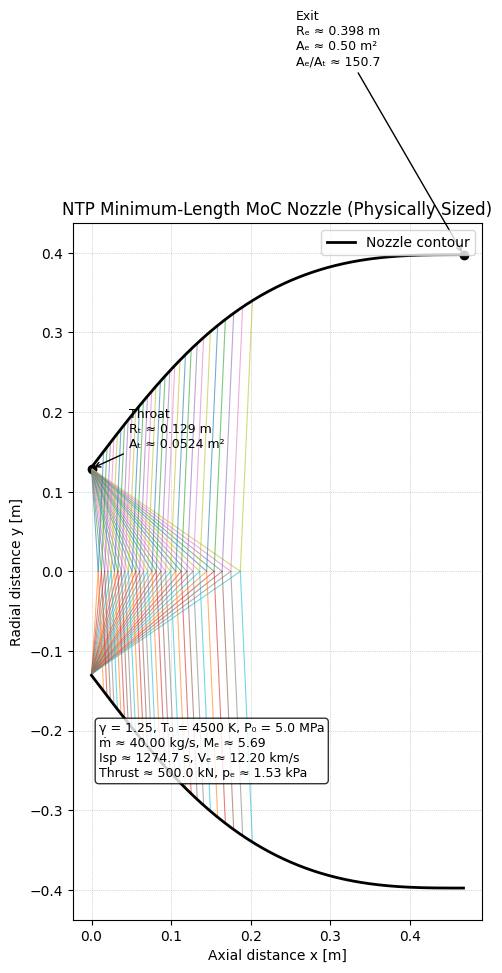

In [ ]:
chars_minus_ntp, chars_plus_ntp, xw_norm, yw_norm = design_min_length_nozzle(
    Me=Me_ntp, gamma=gamma_ntp, n_waves=30, Rt=1.0
)

# Scale to physical meters using Rt_phys
xw = np.array(xw_norm) * Rt_phys
yw = np.array(yw_norm) * Rt_phys

chars_minus_phys = [
    [(x * Rt_phys, y * Rt_phys) for (x, y) in ch] for ch in chars_minus_ntp
]
chars_plus_phys = [
    [(x * Rt_phys, y * Rt_phys) for (x, y) in ch] for ch in chars_plus_ntp
]

x_exit = xw[-1]
R_exit = abs(yw[-1])
Ae_MoC = math.pi * R_exit**2

print("=== MoC geometry summary ===")
print(f"Nozzle length ≈ {x_exit:.3f} m")
print(f"Exit radius from MoC ≈ {R_exit:.3f} m")
print(f"Exit area from MoC ≈ {Ae_MoC:.2f} m²\n")

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

# C- characteristics
for ch in chars_minus_phys:
    xs = [p[0] for p in ch]
    ys = [p[1] for p in ch]
    ax.plot(xs, ys, linewidth=0.8, alpha=0.6)
    ax.plot(xs, [-y for y in ys], linewidth=0.8, alpha=0.6)

# C+ characteristics
for ch in chars_plus_phys:
    xs = [p[0] for p in ch]
    ys = [p[1] for p in ch]
    ax.plot(xs, ys, linewidth=0.8, alpha=0.6)
    ax.plot(xs, [-y for y in ys], linewidth=0.8, alpha=0.6)

# Nozzle wall contour
ax.plot(xw,  yw,  "k", linewidth=2, label="Nozzle contour")
ax.plot(xw, -yw, "k", linewidth=2)

# Throat annotation
ax.scatter([0], [Rt_phys], color="k")
ax.annotate(f"Throat\nRₜ ≈ {Rt_phys:.3f} m\nAₜ ≈ {At:.4f} m²",
            xy=(0, Rt_phys),
            xytext=(0.1 * x_exit, 1.2 * Rt_phys),
            arrowprops=dict(arrowstyle="->", lw=1),
            fontsize=9)

# Exit annotation
ax.scatter([x_exit], [R_exit], color="k")
ax.annotate(
    f"Exit\nRₑ ≈ {R_exit:.3f} m\nAₑ ≈ {Ae_MoC:.2f} m²\nAₑ/Aₜ ≈ {AeAt_ntp:.1f}",
    xy=(x_exit, R_exit),
    xytext=(0.55 * x_exit, 1.6 * R_exit),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=9
)

# Performance text box
text_box = (
    f"γ = {gamma_ntp:.2f}, T₀ = {T0_ntp:.0f} K, P₀ = {Pc_ntp/1e6:.1f} MPa\n"
    f"ṁ ≈ {mdot_ntp:.2f} kg/s, Mₑ ≈ {Me_ntp:.2f}\n"
    f"Isp ≈ {Isp_ntp:.1f} s, Vₑ ≈ {Ve_ntp/1000:.2f} km/s\n"
    f"Thrust ≈ {thrust_ntp/1000:.1f} kN, pₑ ≈ {pe_ntp/1000:.2f} kPa"
)
ax.text(0.02 * x_exit, -2.0 * Rt_phys, text_box, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Axial distance x [m]")
ax.set_ylabel("Radial distance y [m]")
ax.set_title("NTP Minimum-Length MoC Nozzle (Physically Sized)")
ax.grid(True, linestyle=":", linewidth=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

=== Ion Source Trade for Isp = 50,000 s ===
Target exhaust velocity v_e = 490.5 km/s
Total NEP propellant mass   = 957.3 t

 Ion      m_i [kg]    V_accel [kV]     E_ion [keV]   ρ_liq [kg/m³]   Tank V [m³]
--------------------------------------------------------------------------------
 H2⁺     3.321e-27             2.5             2.5            70.0       13675.1
 He⁺     6.642e-27             5.0             5.0           125.0        7658.1
 N2⁺     4.649e-26            34.9            34.9           800.0        1196.6
 Xe⁺     2.175e-25           163.3           163.3          3000.0         319.1
 Li⁺     1.162e-26             8.7             8.7           534.0        1792.6


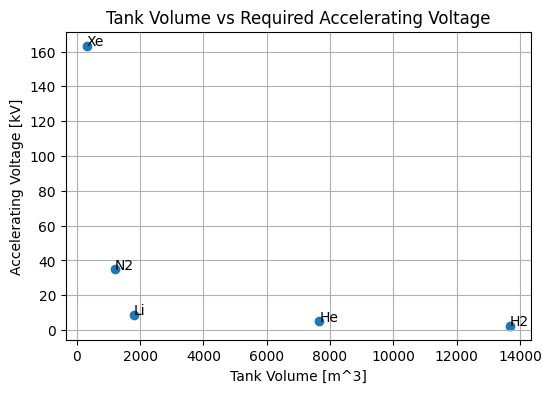

In [ ]:
g0 = 9.81          # m/s²
q  = 1.602e-19     # C (elementary charge)

Isp_target = 50_000.0
ve_target  = Isp_target * g0  # m/s

mp_nep = 957258.2   # kg of NEP propellant from earlier rocket eq

# Rough liquid densities [kg/m³] (order-of-magnitude)
rho_liquid = {
    "H2":   70.0,    # liquid hydrogen
    "He":   125.0,   # liquid helium (very rough)
    "N2":   800.0,   # liquid nitrogen-ish
    "Xe":   3000.0,  # liquid xenon ~3.0 g/cc
    "Li":   534.0,   # liquid lithium
}

# Ion masses [kg] (assuming singly ionized molecules/atoms)
amu = 1.6605e-27

ion_data = {
    "H2⁺" : 2.0  * amu,
    "He⁺" : 4.0  * amu,
    "N2⁺" : 28.0 * amu,
    "Xe⁺" : 131.0 * amu,
    "Li⁺" : 7.0  * amu,
}

print("=== Ion Source Trade for Isp = 50,000 s ===")
print(f"Target exhaust velocity v_e = {ve_target/1e3:.1f} km/s")
print(f"Total NEP propellant mass   = {mp_nep/1e3:.1f} t\n")

header = f"{'Ion':>4s}  {'m_i [kg]':>12s}  {'V_accel [kV]':>14s}  {'E_ion [keV]':>14s}  {'ρ_liq [kg/m³]':>14s}  {'Tank V [m³]':>12s}"
print(header)
print("-" * len(header))

for label, m_i in ion_data.items():
    # required accelerating voltage for given v_e
    V = m_i * ve_target**2 / (2 * q)   # volts
    E_eV = V                           # eV per ion (since q=1e)

    # choose density based on atom/molecule identity
    species = label.replace("⁺","")    # crude map: "H2", "He", "N2", "Xe"
    rho = rho_liquid.get(species, None)
    if rho is not None:
        tank_volume = mp_nep / rho   # m³
    else:
        tank_volume = np.nan

    print(f"{label:>4s}  {m_i:12.3e}  {V/1e3:14.1f}  {E_eV/1e3:14.1f}  {rho if rho is not None else float('nan'):14.1f}  {tank_volume:12.1f}")

amu=1.6605e-27
# ions
ions={"H2":2*amu,"He":4*amu,"N2":28*amu,"Xe":131*amu, "Li":7*amu}
# densities
rho={"H2":70.0,"He":125.0,"N2":800.0,"Xe":3000.0, "Li": 534.0}

mp=957258.2

tank_vol=[]
volt=[]
labels=[]
for species,m_i in ions.items():
    V = m_i*ve_target**2/(2*q)
    vol = mp/rho[species]
    tank_vol.append(vol)
    volt.append(V/1e3) # kV
    labels.append(species)

plt.figure(figsize=(6,4))
plt.scatter(tank_vol, volt)
for x,y,l in zip(tank_vol,volt,labels):
    plt.text(x,y,l)
plt.xlabel("Tank Volume [m^3]")
plt.ylabel("Accelerating Voltage [kV]")
plt.title("Tank Volume vs Required Accelerating Voltage")
plt.grid(True)
plt.show()

=== Inbound ellipse for solar Oberth schematic ===
a = 0.507 AU, e = 0.972
Numerical perihelion radius ~ 0.0140 AU
Perihelion speed (elliptic)  = 352.78 km/s
Required perihelion speed    = 355.17 km/s
Impulsive Δv at perihelion   = 2.39 km/s


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


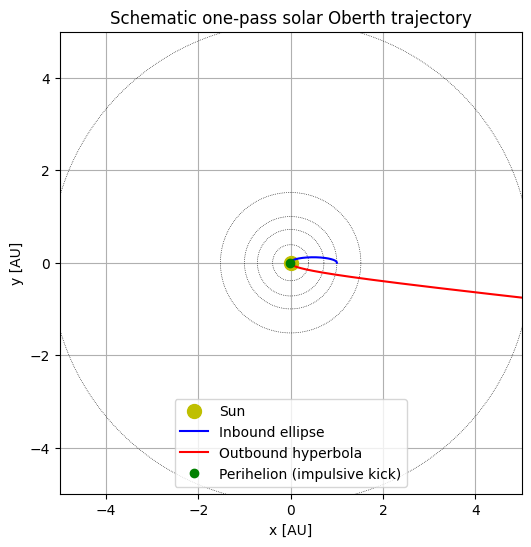

=== Inbound ellipse for solar Oberth schematic ===
a = 0.507 AU, e = 0.972
Numerical perihelion radius ~ 0.0140 AU
Perihelion speed (elliptic)  = 353.51 km/s
Required perihelion speed    = 355.98 km/s
Impulsive Δv at perihelion   = 2.46 km/s


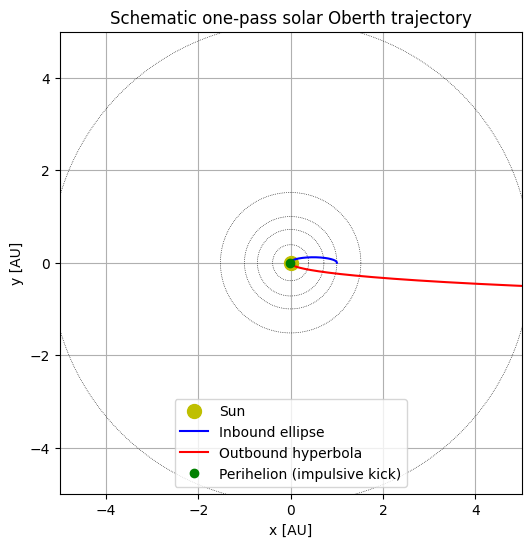

In [ ]:
mu_s = 1.32712440018e20
year = 365.25 * 24 * 3600
def two_body_derivs(state, mu):
    x, y, vx, vy = state
    r3 = (x**2 + y**2)**1.5
    ax = -mu * x / r3
    ay = -mu * y / r3
    return np.array([vx, vy, ax, ay])

def rk2_step(state, dt, mu):
    k1 = two_body_derivs(state, mu)
    mid_state = state + 0.5 * dt * k1
    k2 = two_body_derivs(mid_state, mu)
    return state + dt * k2

# Design: inbound ellipse with aphelion Q = 1 AU, perihelion q = 0.005 AU
r_ap = 1 * AU
r_p  = 0.014 * AU
a_ell = 0.5 * (r_ap + r_p)
e_ell = (r_ap - r_p) / (r_ap + r_p)

print("=== Inbound ellipse for solar Oberth schematic ===")
print(f"a = {a_ell/AU:.3f} AU, e = {e_ell:.3f}")

# Initial at aphelion
x0 = r_ap
y0 = 0.0
v_ap = np.sqrt(mu_s * (2.0/x0 - 1.0/a_ell))
vx0 = 0.0
vy0 = v_ap

state = np.array([x0, y0, vx0, vy0])

dt_inbound   = 500.0
t_inbound_max = 5.0 * year

t_inbound = [0.0]
xs_in     = [state[0]]
ys_in     = [state[1]]

min_r = np.linalg.norm(state[:2])

# Integrate inbound to perihelion
while t_inbound[-1] < t_inbound_max:
    new_state = rk2_step(state, dt_inbound, mu_s)
    r_old = np.linalg.norm(state[:2])
    r_new = np.linalg.norm(new_state[:2])

    t_inbound.append(t_inbound[-1] + dt_inbound)
    xs_in.append(new_state[0])
    ys_in.append(new_state[1])

    state = new_state
    if r_new < min_r:
        min_r = r_new
    else:
        break

print(f"Numerical perihelion radius ~ {min_r/AU:.4f} AU")

# Perihelion state
x_p, y_p, vx_p, vy_p = state
r_p_num = np.linalg.norm([x_p, y_p])

# Impulsive kick to some v_inf (e.g. 500 km/s pre-NEP)
v_inf_target = 0  # m/s
v_p_ell = np.linalg.norm([vx_p, vy_p])
v_p_hyp = np.sqrt(v_inf_target**2 + 2.0*mu_s/r_p_num)
delta_v = v_p_hyp - v_p_ell

print(f"Perihelion speed (elliptic)  = {v_p_ell/1e3:.2f} km/s")
print(f"Required perihelion speed    = {v_p_hyp/1e3:.2f} km/s")
print(f"Impulsive Δv at perihelion   = {delta_v/1e3:.2f} km/s")

# Apply Δv tangentially
r_vec  = np.array([x_p, y_p])
v_vec  = np.array([vx_p, vy_p])
r_hat  = r_vec / np.linalg.norm(r_vec)
v_rad  = np.dot(v_vec, r_hat) * r_hat
v_tan  = v_vec - v_rad
vt_hat = v_tan / np.linalg.norm(v_tan)

v_vec_new = v_rad + vt_hat * v_p_hyp
state_out = np.array([x_p, y_p, v_vec_new[0], v_vec_new[1]])

# Outbound hyperbolic integration
dt_outbound    = 500.0
t_outbound_max = 30.0 * year

t_outbound = [t_inbound[-1]]
xs_out     = [state_out[0]]
ys_out     = [state_out[1]]

state = state_out.copy()

while t_outbound[-1] - t_outbound[0] < t_outbound_max:
    state = rk2_step(state, dt_outbound, mu_s)
    t_outbound.append(t_outbound[-1] + dt_outbound)
    xs_out.append(state[0])
    ys_out.append(state[1])

# Convert to AU for plotting
xs_in_AU  = np.array(xs_in) / AU
ys_in_AU  = np.array(ys_in) / AU
xs_out_AU = np.array(xs_out) / AU
ys_out_AU = np.array(ys_out) / AU

# Plot
fig, ax = plt.subplots(figsize=(6,6))

# Sun
ax.plot(0, 0, 'yo', markersize=10, label="Sun")

# Planet orbits for context
theta_circle = np.linspace(0, 2*np.pi, 400)
for R in [0.39, 0.72, 1.0, 1.52, 5.2]:
    ax.plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k:', linewidth=0.5)

ax.plot(xs_in_AU, ys_in_AU, 'b', label="Inbound ellipse")
ax.plot(xs_out_AU, ys_out_AU, 'r', label="Outbound hyperbola")

ax.plot(xs_in_AU[-1], ys_in_AU[-1], 'go', label="Perihelion (impulsive kick)")

ax.set_aspect('equal', 'box')
ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")
ax.set_title("Schematic one-pass solar Oberth trajectory")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.grid(True)
ax.legend()
plt.show()
def two_body_derivs(state, mu):
    x, y, vx, vy = state
    r3 = (x**2 + y**2)**1.5
    ax = -mu * x / r3
    ay = -mu * y / r3
    return np.array([vx, vy, ax, ay])

def rk2_step(state, dt, mu):
    k1 = two_body_derivs(state, mu)
    mid_state = state + 0.5 * dt * k1
    k2 = two_body_derivs(mid_state, mu)
    return state + dt * k2

# Design: inbound ellipse with aphelion Q = 1 AU, perihelion q = 0.005 AU
r_ap = 1 * AU
r_p  = 0.014 * AU
a_ell = 0.5 * (r_ap + r_p)
e_ell = (r_ap - r_p) / (r_ap + r_p)

print("=== Inbound ellipse for solar Oberth schematic ===")
print(f"a = {a_ell/AU:.3f} AU, e = {e_ell:.3f}")

# Initial at aphelion
x0 = r_ap
y0 = 0.0
v_ap = np.sqrt(mu_s * (2.0/x0 - 1.0/a_ell))
vx0 = 0.0
vy0 = v_ap

state = np.array([x0, y0, vx0, vy0])

dt_inbound   = 100.0
t_inbound_max = 5.0 * year

t_inbound = [0.0]
xs_in     = [state[0]]
ys_in     = [state[1]]

min_r = np.linalg.norm(state[:2])

# Integrate inbound to perihelion
while t_inbound[-1] < t_inbound_max:
    new_state = rk2_step(state, dt_inbound, mu_s)
    r_old = np.linalg.norm(state[:2])
    r_new = np.linalg.norm(new_state[:2])

    t_inbound.append(t_inbound[-1] + dt_inbound)
    xs_in.append(new_state[0])
    ys_in.append(new_state[1])

    state = new_state
    if r_new < min_r:
        min_r = r_new
    else:
        break

print(f"Numerical perihelion radius ~ {min_r/AU:.4f} AU")

# Perihelion state
x_p, y_p, vx_p, vy_p = state
r_p_num = np.linalg.norm([x_p, y_p])

# Impulsive kick to some v_inf (e.g. 500 km/s pre-NEP)
v_inf_target = 0  # m/s
v_p_ell = np.linalg.norm([vx_p, vy_p])
v_p_hyp = np.sqrt(v_inf_target**2 + 2.0*mu_s/r_p_num)
delta_v = v_p_hyp - v_p_ell

print(f"Perihelion speed (elliptic)  = {v_p_ell/1e3:.2f} km/s")
print(f"Required perihelion speed    = {v_p_hyp/1e3:.2f} km/s")
print(f"Impulsive Δv at perihelion   = {delta_v/1e3:.2f} km/s")

# Apply Δv tangentially
r_vec  = np.array([x_p, y_p])
v_vec  = np.array([vx_p, vy_p])
r_hat  = r_vec / np.linalg.norm(r_vec)
v_rad  = np.dot(v_vec, r_hat) * r_hat
v_tan  = v_vec - v_rad
vt_hat = v_tan / np.linalg.norm(v_tan)

v_vec_new = v_rad + vt_hat * v_p_hyp
state_out = np.array([x_p, y_p, v_vec_new[0], v_vec_new[1]])

# Outbound hyperbolic integration
dt_outbound    = 500.0
t_outbound_max = 30.0 * year

t_outbound = [t_inbound[-1]]
xs_out     = [state_out[0]]
ys_out     = [state_out[1]]

state = state_out.copy()

while t_outbound[-1] - t_outbound[0] < t_outbound_max:
    state = rk2_step(state, dt_outbound, mu_s)
    t_outbound.append(t_outbound[-1] + dt_outbound)
    xs_out.append(state[0])
    ys_out.append(state[1])

# Convert to AU for plotting
xs_in_AU  = np.array(xs_in) / AU
ys_in_AU  = np.array(ys_in) / AU
xs_out_AU = np.array(xs_out) / AU
ys_out_AU = np.array(ys_out) / AU

# Plot
fig, ax = plt.subplots(figsize=(6,6))

# Sun
ax.plot(0, 0, 'yo', markersize=10, label="Sun")

# Planet orbits for context
theta_circle = np.linspace(0, 2*np.pi, 400)
for R in [0.39, 0.72, 1.0, 1.52, 5.2]:
    ax.plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k:', linewidth=0.5)

ax.plot(xs_in_AU, ys_in_AU, 'b', label="Inbound ellipse")
ax.plot(xs_out_AU, ys_out_AU, 'r', label="Outbound hyperbola")

ax.plot(xs_in_AU[-1], ys_in_AU[-1], 'go', label="Perihelion (impulsive kick)")

ax.set_aspect('equal', 'box')
ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")
ax.set_title("Schematic one-pass solar Oberth trajectory")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.grid(True)
ax.legend()
plt.show()

In [ ]:
g0 = 9.80665
Isp_ntp = 1274.6868667494684  # s
mdot_ntp = 40.0               # kg/s
dv1 = 24_840.0                # m/s, 24.84 km/s

def ntp_two_burn_analytic(m0, m_dry, v0=0.0, t_coast=0.0,
                          n1=500, n_coast=200, n2=500):
    """
    Analytic NTP profile with:
      - Burn 1 from t=0 to Δv1 = 24.84 km/s
      - Coast for t_coast with NTP off
      - Burn 2 at perihelion until all NTP prop is gone (mass m=m_dry)

    Inputs:
      m0      : initial mass at t=0 (kg), incl. NTP prop + NEP + payload
      m_dry   : mass after all NTP prop consumed (kg)
      v0      : initial velocity at t=0 (m/s) in chosen frame
      t_coast : coast time between burns (s) – from your orbital calc
      n1, n_coast, n2 : number of sample points for plots for each phase

    Returns dict with concatenated arrays:
      't', 'm', 'v', 'a', and some scalar burn info.
    """
    Isp = Isp_ntp
    mdot = mdot_ntp
    T = Isp * g0 * mdot

    # === Burn 1: solve for m1, t1 ===
    dv1 = 24_840.0  # m/s

    # Check max possible delta-v
    dv_max = Isp * g0 * math.log(m0 / m_dry)
    if dv1 >= dv_max:
        raise ValueError(f"Requested Δv1={dv1/1e3:.2f} km/s exceeds max Δv={dv_max/1e3:.2f} km/s for given m0 and m_dry.")

    m1 = m0 * math.exp(-dv1 / (Isp * g0))
    mprop1 = m0 - m1
    t1 = mprop1 / mdot

    # Time grid for burn 1
    t1_arr = np.linspace(0.0, t1, n1)
    m1_arr = m0 - mdot * t1_arr
    v1_arr = v0 + Isp * g0 * np.log(m0 / m1_arr)
    a1_arr = T / m1_arr

    v1_end = v1_arr[-1]  # should be v0 + dv1

    # === Coast ===
    if t_coast > 0.0 and n_coast > 1:
        t_coast_arr = np.linspace(t1, t1 + t_coast, n_coast)
        m_coast_arr = np.full_like(t_coast_arr, m1)
        v_coast_arr = np.full_like(t_coast_arr, v1_end)  # ignoring gravity for NTP-only view
        a_coast_arr = np.zeros_like(t_coast_arr)
    else:
        t_coast_arr = np.array([])
        m_coast_arr = np.array([])
        v_coast_arr = np.array([])
        a_coast_arr = np.array([])

    # === Burn 2: burn remaining propellant ===
    m_burn2_start = m_coast_arr[-1] if t_coast_arr.size > 0 else m1
    t_burn2_start = t_coast_arr[-1] if t_coast_arr.size > 0 else t1

    mprop2 = m_burn2_start - m_dry
    t2 = mprop2 / mdot
    dv2 = Isp * g0 * math.log(m_burn2_start / m_dry)

    t2_arr = np.linspace(t_burn2_start, t_burn2_start + t2, n2)
    m2_arr = m_burn2_start - mdot * (t2_arr - t_burn2_start)
    v2_arr = v1_end + Isp * g0 * np.log(m_burn2_start / m2_arr)
    a2_arr = T / m2_arr

    # === Concatenate results ===
    t_full = np.concatenate((t1_arr, t_coast_arr[1:], t2_arr[1:]))
    m_full = np.concatenate((m1_arr, m_coast_arr[1:], m2_arr[1:]))
    v_full = np.concatenate((v1_arr, v_coast_arr[1:], v2_arr[1:]))
    a_full = np.concatenate((a1_arr, a_coast_arr[1:], a2_arr[1:]))

    return {
        "t": t_full,
        "m": m_full,
        "v": v_full,
        "a": a_full,
        "dv1": dv1,
        "dv2": dv2,
        "dv_total": dv1 + dv2,
        "t_burn1": t1,
        "t_burn2": t2,
    }

Δv1 = 24.84 km/s
Δv2 = 6.77 km/s
Total NTP Δv = 31.61 km/s
Burn 1 time = 73.77 h
Burn 2 time = 4.90 h


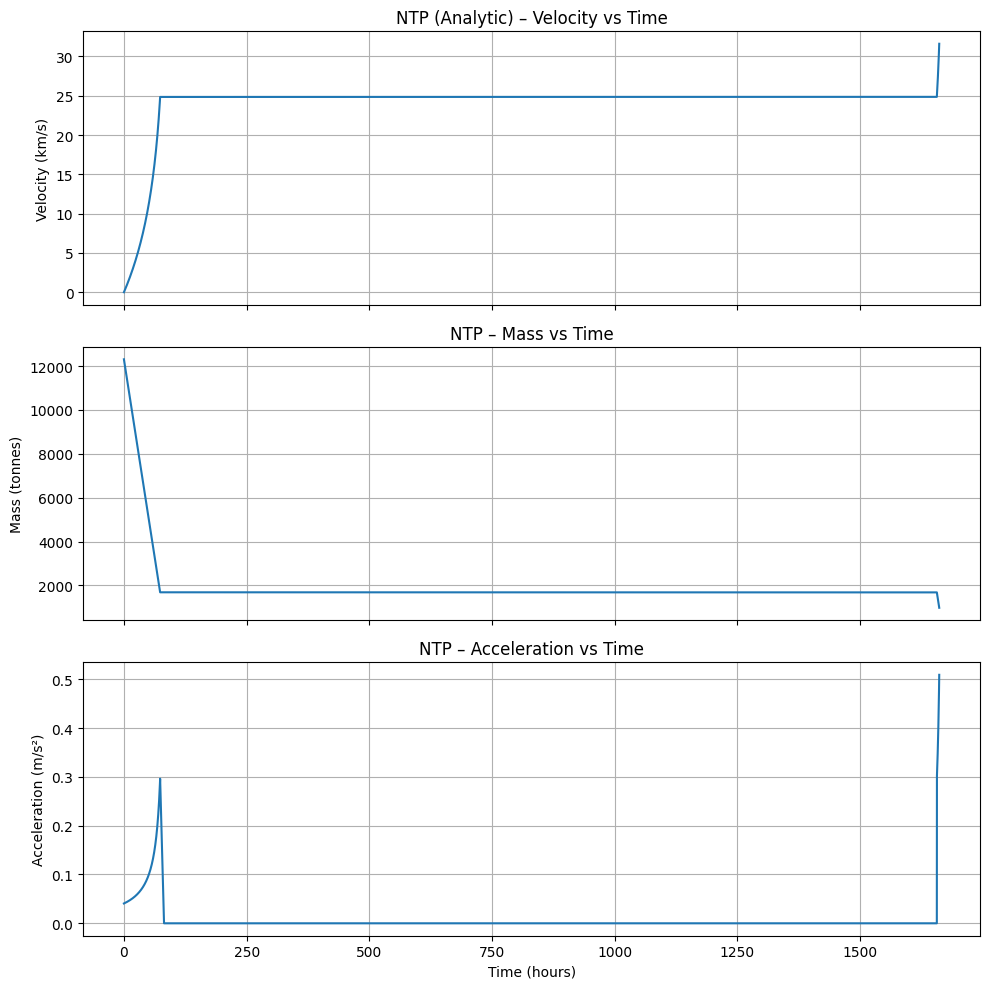

In [ ]:
m0_example = m0_ntp     # kg (example)
m_dry_example = m_final_after_ntp  # kg (example)
t_coast_example = 5696316.51  # s (placeholder; use your orbital calc)

ntp = ntp_two_burn_analytic(m0_example, m_dry_example, v0=0.0, t_coast=t_coast_example)

t = ntp["t"]
m = ntp["m"] / 1e3    # tonnes
v = ntp["v"] / 1e3    # km/s
a = ntp["a"]          # m/s^2

print(f"Δv1 = {ntp['dv1']/1e3:.2f} km/s")
print(f"Δv2 = {ntp['dv2']/1e3:.2f} km/s")
print(f"Total NTP Δv = {ntp['dv_total']/1e3:.2f} km/s")
print(f"Burn 1 time = {ntp['t_burn1']/3600:.2f} h")
print(f"Burn 2 time = {ntp['t_burn2']/3600:.2f} h")

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].plot(t/3600, v)
axs[0].set_ylabel("Velocity (km/s)")
axs[0].set_title("NTP (Analytic) – Velocity vs Time")
axs[0].grid(True)

axs[1].plot(t/3600, m)
axs[1].set_ylabel("Mass (tonnes)")
axs[1].set_title("NTP – Mass vs Time")
axs[1].grid(True)

axs[2].plot(t/3600, a)
axs[2].set_xlabel("Time (hours)")
axs[2].set_ylabel("Acceleration (m/s²)")
axs[2].set_title("NTP – Acceleration vs Time")
axs[2].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# radiator sizing needs

P_electric = 10e6 # 10 MW produced
eta_electric = 0.6 # 40% efficient
eta_thruster = 1 # 100% efficient thruster, unrealistic but let's just say future technology or smth
P_produced = P_electric * eta_electric * eta_thruster
sigma = 5.67e-8 # Stefan-Boltzmann constant
epsilon = 0.8 # emissivity

P_waste = P_electric - P_produced

radiator_capability = 600 # W/m^2

rad_area = P_waste / radiator_capability

#Algebra, ignore
#A_rad = P_waste / (epsilon * sigma * T_rad**4)
#(epsilon * sigma * T_rad**4) = P_waste / A_rad
#T_rad = (P_waste / (epsilon * sigma * A_rad))**0.25

T_rad = (P_waste / (epsilon * sigma * rad_area))**0.25

print(f"P_waste = {P_waste:.2f} W")
print(f"Required radiator area = {rad_area:.2f} m^2")
print(f"Required radiator temperature = {T_rad:.2f} K")


P_waste = 4000000.00 W
Required radiator area = 6666.67 m^2
Required radiator temperature = 339.13 K
